In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

%precision 3
%matplotlib inline
pd.set_option('display.float_format', '{:.3f}'.format)

In [2]:
#아래는 한글을 사용할 때 깨지는 문제에 대한 해결
from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family=font_name)

#그래프의 축 등에서 음수를 표시할 때 minus sign이 깨지는 것 해결
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv('../통계분석2/받은 파일/data/mapo_delivery_3months_50k_dirty.csv')
df

,order_id,order_time,pickup_time,delivery_time,store_dong,customer_dong,distance_km,store_type,weather,temp_c,precipitation_mm,wind_mps,rider_id,time_slot,dow,delivery_minutes
0,O000001,2025.10.24 15:46:54,2025-10-24 16:03:49,10/24 04:07 PM,아현동,신수동,1.170,치킨,Sunny,5.100,0.000,1.200,R0062,기타,4,20.900
1,O000002,2025-12-25 06:44:42,2025-12-25 07:00:15,2025-12-25 07:07:36,망원동,도화동,0.200,야식,비,10.900,4.900,4.600,R0362,기타,3,NaN
2,O000003,2025.12.14 12:52:27,2025-12-14 13:07:15,12/14/2025 13:14,용강동,신촌동,0.360,패스트푸드,비,6.300,2.000,5.100,R0223,점심,6,21.900
3,O000004,2025-11-25 02:58,2025-11-25 03:11:05,2025-11-25 03:40:26,공덕동,서교동,3.590,한식,흐림,5.400,0.000,0.800,R0722,심야,1,41.800
4,O000005,2025-11-24 14:18:45,2025-11-24 14:30:10,NaN,성산동,대흥동,2.540,패스트푸드,맑음,8.600,0.000,5.000,R0128,기타,0,44.300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,O049996,2025-10-21 23:33:36,2025-10-21 23:53:37,2025-10-22 00:21:00,용강동,합정동,3.390,피자,비,8.900,9.500,4.500,R0645,야식,1,47.400
49996,O049997,2025-12-11 22:18:25,12/11/2025 22:35,2025-12-11 22:47:07,신촌동,성산동,1.870,한식,흐림,10.500,0.000,2.000,R0088,야식,3,28.700
49997,O049998,2025-11-12 20:26:28,2025-11-12 20:51:29,2025-11-12 21:06:22,대흥동,망원동,2.760,야식,흐림,5.200,0.000,4.100,R0041,저녁,2,39.900
49998,O049999,2025-12-19 00:22,2025-12-19 00:31:49,2025-12-19 00:48:28,연남동,용강동,1.740,카페/디저트,흐림,3.000,0.000,3.200,R0716,심야,4,25.600


In [5]:
print(type(df['order_id'][0]))
print(type(df['order_time'][0]))
print(type(df['pickup_time'][0]))
print(type(df['delivery_time'][0]))
print(type(df['store_dong'][0]))
print(type(df['customer_dong'][0]))
print(type(df['distance_km'][0]))
print(type(df['store_type'][0]))
print(type(df['weather'][0]))
print(type(df['temp_c'][0]))
print(type(df['precipitation_mm'][0]))
print(type(df['wind_mps'][0]))
print(type(df['rider_id'][0]))
print(type(df['time_slot'][0]))
print(type(df['dow'][0]))
print(type(df['delivery_minutes'][0]))

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'numpy.float64'>
<class 'str'>
<class 'str'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'str'>
<class 'str'>
<class 'numpy.int64'>
<class 'numpy.float64'>


In [67]:
df['order_id'].unique() #106개 중복

array(['O000001', 'O000002', 'O000003', ..., 'O049998', 'O049999',
       'O050000'], shape=(49894,), dtype=object)

In [50]:
# dayfirst=False (월/일/연 처리), yearfirst=True (연/월/일 처리) 등 옵션 조절 가능
# errors='coerce'는 변환 불가한 데이터를 NaT(결측치)로 처리
lst = ['order_time', 'pickup_time', 'delivery_time']
for i in lst:
    temp_dt = pd.to_datetime(df[i], yearfirst=True, errors='coerce')
    prefix = i.replace('_time', '') # 'order', 'pickup' 등 접두어 추출
    
    df[f'{prefix}_year']  = temp_dt.dt.year.astype('Int64')
    df[f'{prefix}_month'] = temp_dt.dt.month.astype('Int64')
    df[f'{prefix}_day']   = temp_dt.dt.day.astype('Int64')
    df[f'{prefix}_t']     = temp_dt.dt.strftime('%H:%M:%S')

df2 = pd.DataFrame(df[['order_year','order_month','order_day','order_t','pickup_year','pickup_month','pickup_day','pickup_t','delivery_year','delivery_month','delivery_day','delivery_t']])
cols = [c for c in df2.columns if '_t' not in c] # 시간(_t) 제외한 연, 월, 일 컬럼들
for col in cols:
    df2[col] = df2[col].astype('Int64')

for unit in ['year', 'month', 'day', 't']:
    target = f'order_{unit}'
    p_src = f'pickup_{unit}'
    d_src = f'delivery_{unit}'
    
    # order가 NaN이면 pickup 값을, pickup도 NaN이면 delivery 값을 채움
    df2[target] = df2[target].fillna(df2[p_src]).fillna(df2[d_src])
    # [역방향] 혹시 pickup이나 delivery가 비었을 경우를 위해 order 정보를 역으로 전달
    df2[p_src] = df2[p_src].fillna(df2[target])
    df2[d_src] = df2[d_src].fillna(df2[target])
    
df2['order_h'] = df2['order_t'].str.split(':').str[0].astype(float)

df2.to_csv('tempdata.csv', index = False, encoding = 'utf-8')
df2.head(15)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_2852\2769759916.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_dt = pd.to_datetime(df[i], yearfirst=True, errors='coerce')


,order_year,order_month,order_day,order_t,pickup_year,pickup_month,pickup_day,pickup_t,delivery_year,delivery_month,delivery_day,delivery_t,order_h
0,2025,10,24,15:46:54,2025,10,24,16:03:49,2025,10,24,15:46:54,15.000
1,2025,12,25,07:00:15,2025,12,25,07:00:15,2025,12,25,07:07:36,7.000
2,2025,12,14,12:52:27,2025,12,14,13:07:15,2025,12,14,13:14:00,12.000
3,2025,11,25,03:11:05,2025,11,25,03:11:05,2025,11,25,03:40:26,3.000
4,2025,11,24,14:30:10,2025,11,24,14:30:10,2025,11,24,14:30:10,14.000
5,2026,1,1,21:50:55,2026,1,1,21:50:55,2026,1,1,21:50:55,21.000
6,2025,10,24,08:54:58,2025,10,24,08:54:58,2025,10,24,09:19:26,8.000
7,2025,12,18,09:34:33,2025,12,18,09:34:33,2025,12,18,09:55:47,9.000
8,2025,11,3,18:32:17,2025,11,3,18:32:17,2025,11,3,18:50:20,18.000
9,2025,10,25,02:51:46,2025,10,25,02:51:46,2025,10,25,02:51:46,2.000


In [51]:
df['time_slot'].unique()

array(['기타', '점심', '심야', '야식', '저녁'], dtype=object)

In [65]:
df3 = pd.DataFrame(df[df['time_slot']=='심야'])
df3['order_t'].sort_values().unique()

array(['00:00:06', '00:01:54', '00:02:06', '00:02:40', '00:04:11',
       '00:04:36', '00:06:17', '00:06:48', '00:07:01', '00:09:38',
       '00:09:45', '00:11:01', '00:11:18', '00:11:41', '00:13:00',
       '00:13:12', '00:13:40', '00:15:06', '00:15:39', '00:15:44',
       '00:16:42', '00:16:59', '00:18:31', '00:18:48', '00:18:49',
       '00:19:26', '00:20:17', '00:20:42', '00:20:47', '00:22:00',
       '00:23:19', '00:23:45', '00:23:48', '00:24:34', '00:24:39',
       '00:25:09', '00:26:48', '00:26:57', '00:27:46', '00:29:49',
       '00:30:16', '00:31:12', '00:31:44', '00:32:08', '00:33:59',
       '00:34:35', '00:34:50', '00:37:30', '00:37:32', '00:37:37',
       '00:39:14', '00:39:25', '00:40:00', '00:40:07', '00:40:23',
       '00:40:29', '00:40:46', '00:42:35', '00:42:52', '00:43:30',
       '00:43:49', '00:44:21', '00:44:48', '00:45:05', '00:45:22',
       '00:45:46', '00:45:47', '00:46:16', '00:47:01', '00:47:32',
       '00:49:45', '00:51:12', '00:51:13', '00:51:52', '00:52:

In [76]:
# 1. 시간대 분류 함수 정의
def categorize_timeslot(hour):
    if 11 <= hour < 14:
        return '점심'
    elif 18 <= hour < 21:
        return '저녁'
    elif 21 <= hour <= 23: # 21, 22, 23시
        return '야식'
    elif 0 <= hour < 3:    # 0, 1, 2시
        return '심야'
    else:
        # 3시~11시(오전), 14시~18시(오후)를 모두 포함
        return '식사 외 시간대'

# 2. df['order_hour'] (아까 만든 숫자형 시간)를 사용하여 재배치
# df2['order_h']를 사용 중이라면 아래와 같이 적용합니다.
df['time_slot'] = df2['order_h'].fillna(0).astype(int).apply(categorize_timeslot)
print(df['time_slot'].value_counts())

time_slot
식사 외 시간대    24624
심야           6983
야식           6368
저녁           6077
점심           5948
Name: count, dtype: int64


In [73]:
df['time_slot'].unique()

array(['기타', '점심', '야식', '저녁', '심야'], dtype=object)

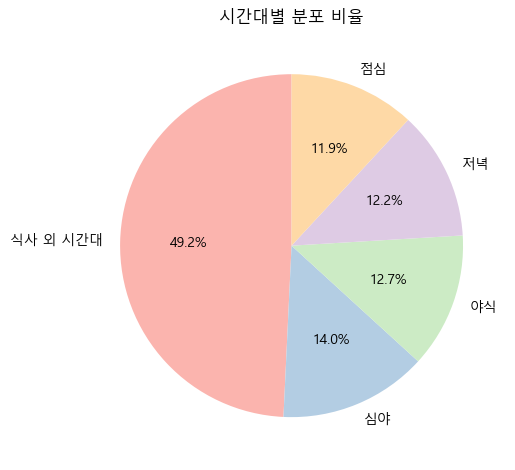

In [77]:
# time_slot 분포 원형 그래프
time_slot_counts = df['time_slot'].value_counts()
plt.pie(time_slot_counts, labels=time_slot_counts.index, autopct='%.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
plt.title('시간대별 분포 비율')

plt.tight_layout()
plt.show()

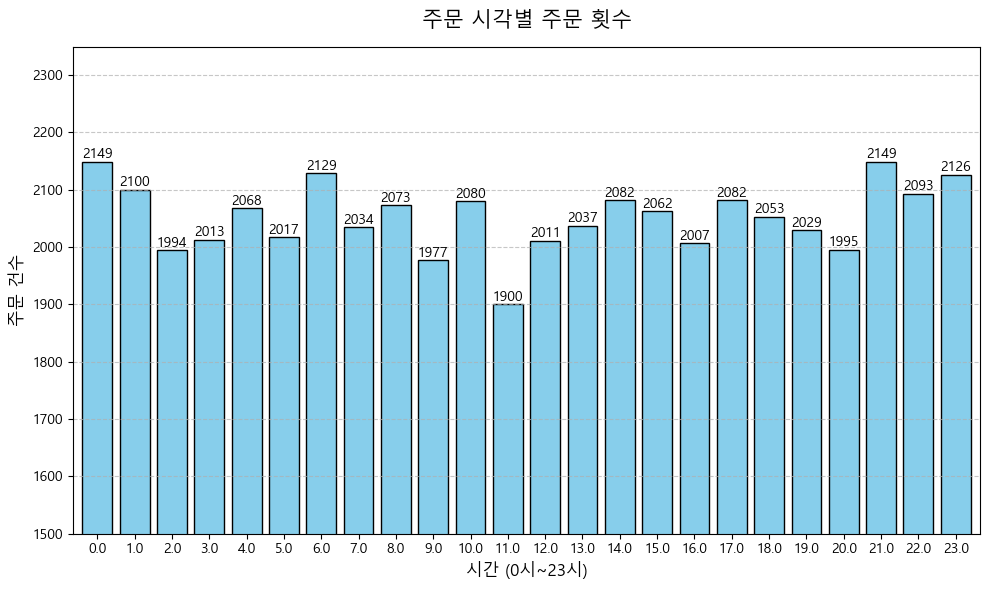

In [25]:
# 주문 시각별 주문 횟수 막대 그래프
plt.figure(figsize=(10, 6))

# 데이터가 비어있는(NaN) 행은 제외하고 카운트
h_counts = df2['order_h'].value_counts().sort_index()

# 주문 시각별 주문 횟수 막대그래프
ax = h_counts.plot(kind='bar', color='skyblue', edgecolor='black', width=0.8)

# 그래프 디테일
plt.title('주문 시각별 주문 횟수', fontsize=15, pad=15)
plt.xlabel('시간 (0시~23시)', fontsize=12)
plt.ylabel('주문 건수', fontsize=12)
plt.xticks(rotation=0) # 시간 숫자를 가로로 바르게 표시
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Y축의 범위를 (최소값, 최대값)으로 설정
plt.ylim(1500, h_counts.max() + 200)

plt.tight_layout()
plt.show()

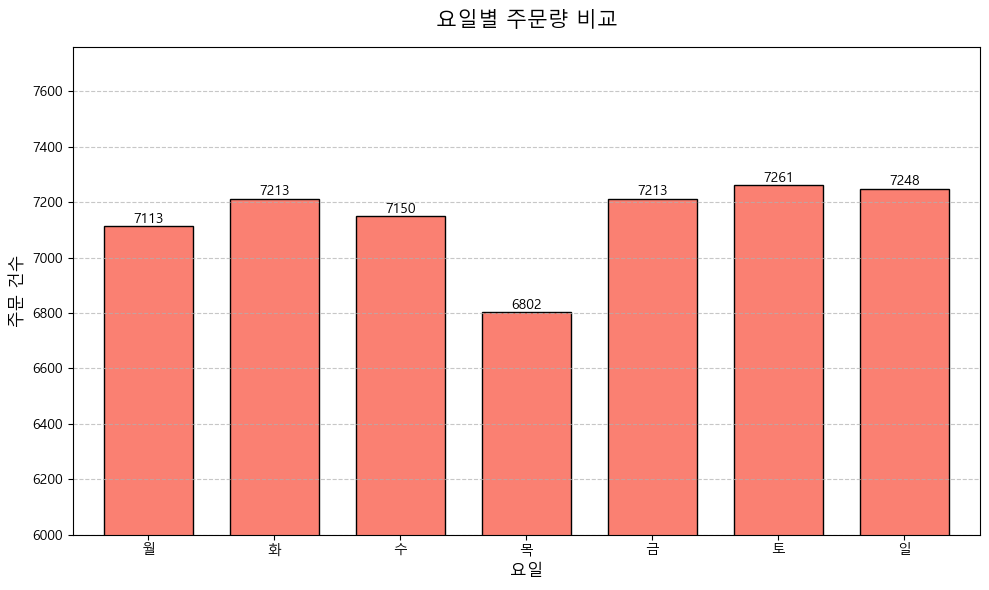

In [26]:
plt.figure(figsize=(10, 6))

# 요일 데이터  전처리
week = ['월', '화', '수', '목', '금', '토', '일']
dow_counts = df['dow'].value_counts().sort_index()
dow_counts.index = [week[i] for i in dow_counts.index]

ax1 = dow_counts.plot(kind='bar', color='salmon', edgecolor='black', width=0.7)

# Y축 범위 설정
plt.ylim(6000, dow_counts.max() + 500)

plt.title('요일별 주문량 비교', fontsize=15, pad=15)
plt.xlabel('요일', fontsize=12)
plt.ylabel('주문 건수', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위 숫자 표시
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [29]:
df['weather'].unique()

array(['Sunny', '비', '흐림', '맑음', '눈', '안개', 'SNOW', 'overcast', '안개🌫',
       '흐림☁', 'FOG', 'rain', 'CLEAR', 'clear', 'cloudy', 'fog', 'snow',
       'sunny', 'RAIN', '비☔', '맑 음', '눈❄', 'shower', '맑음☀', 'Cloudy'],
      dtype=object)

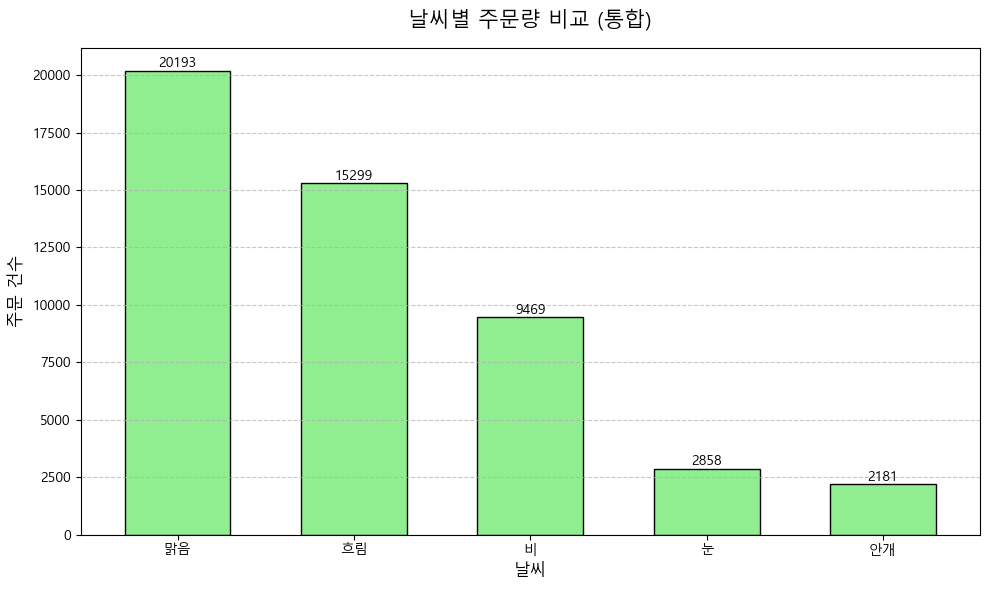

In [30]:
plt.figure(figsize=(10, 6))

# 날씨 데이터 통합 (분류 작업)
weather_mapping = {
    'Sunny': '맑음',
    'sunny': '맑음',
    '맑 음': '맑음',
    '맑음☀': '맑음',
    'Rainy': '비',
    'RAIN': '비',
    '비☔': '비',
    'Cloudy': '흐림',
    'Snowy': '눈',
    'snow': '눈',
    '눈❄': '눈',
    '안개🌫': '안개',
    'SNOW': '눈',
    'overcast': '흐림',
    '흐림☁': '흐림',
    'FOG': '안개',
    'fog': '안개',
    'rain': '비',
    'CLEAR': '맑음',
    'clear': '맑음',
    'cloudy': '흐림',
    'shower': '비',
}
df['weather_clean'] = df['weather'].replace(weather_mapping)

# 통합된 날씨별 카운트
weather_counts = df['weather_clean'].value_counts()

ax2 = weather_counts.plot(kind='bar', color='lightgreen', edgecolor='black', width=0.6)

plt.title('날씨별 주문량 비교 (통합)', fontsize=15, pad=15)
plt.xlabel('날씨', fontsize=12)
plt.ylabel('주문 건수', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위 숫자 표시
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

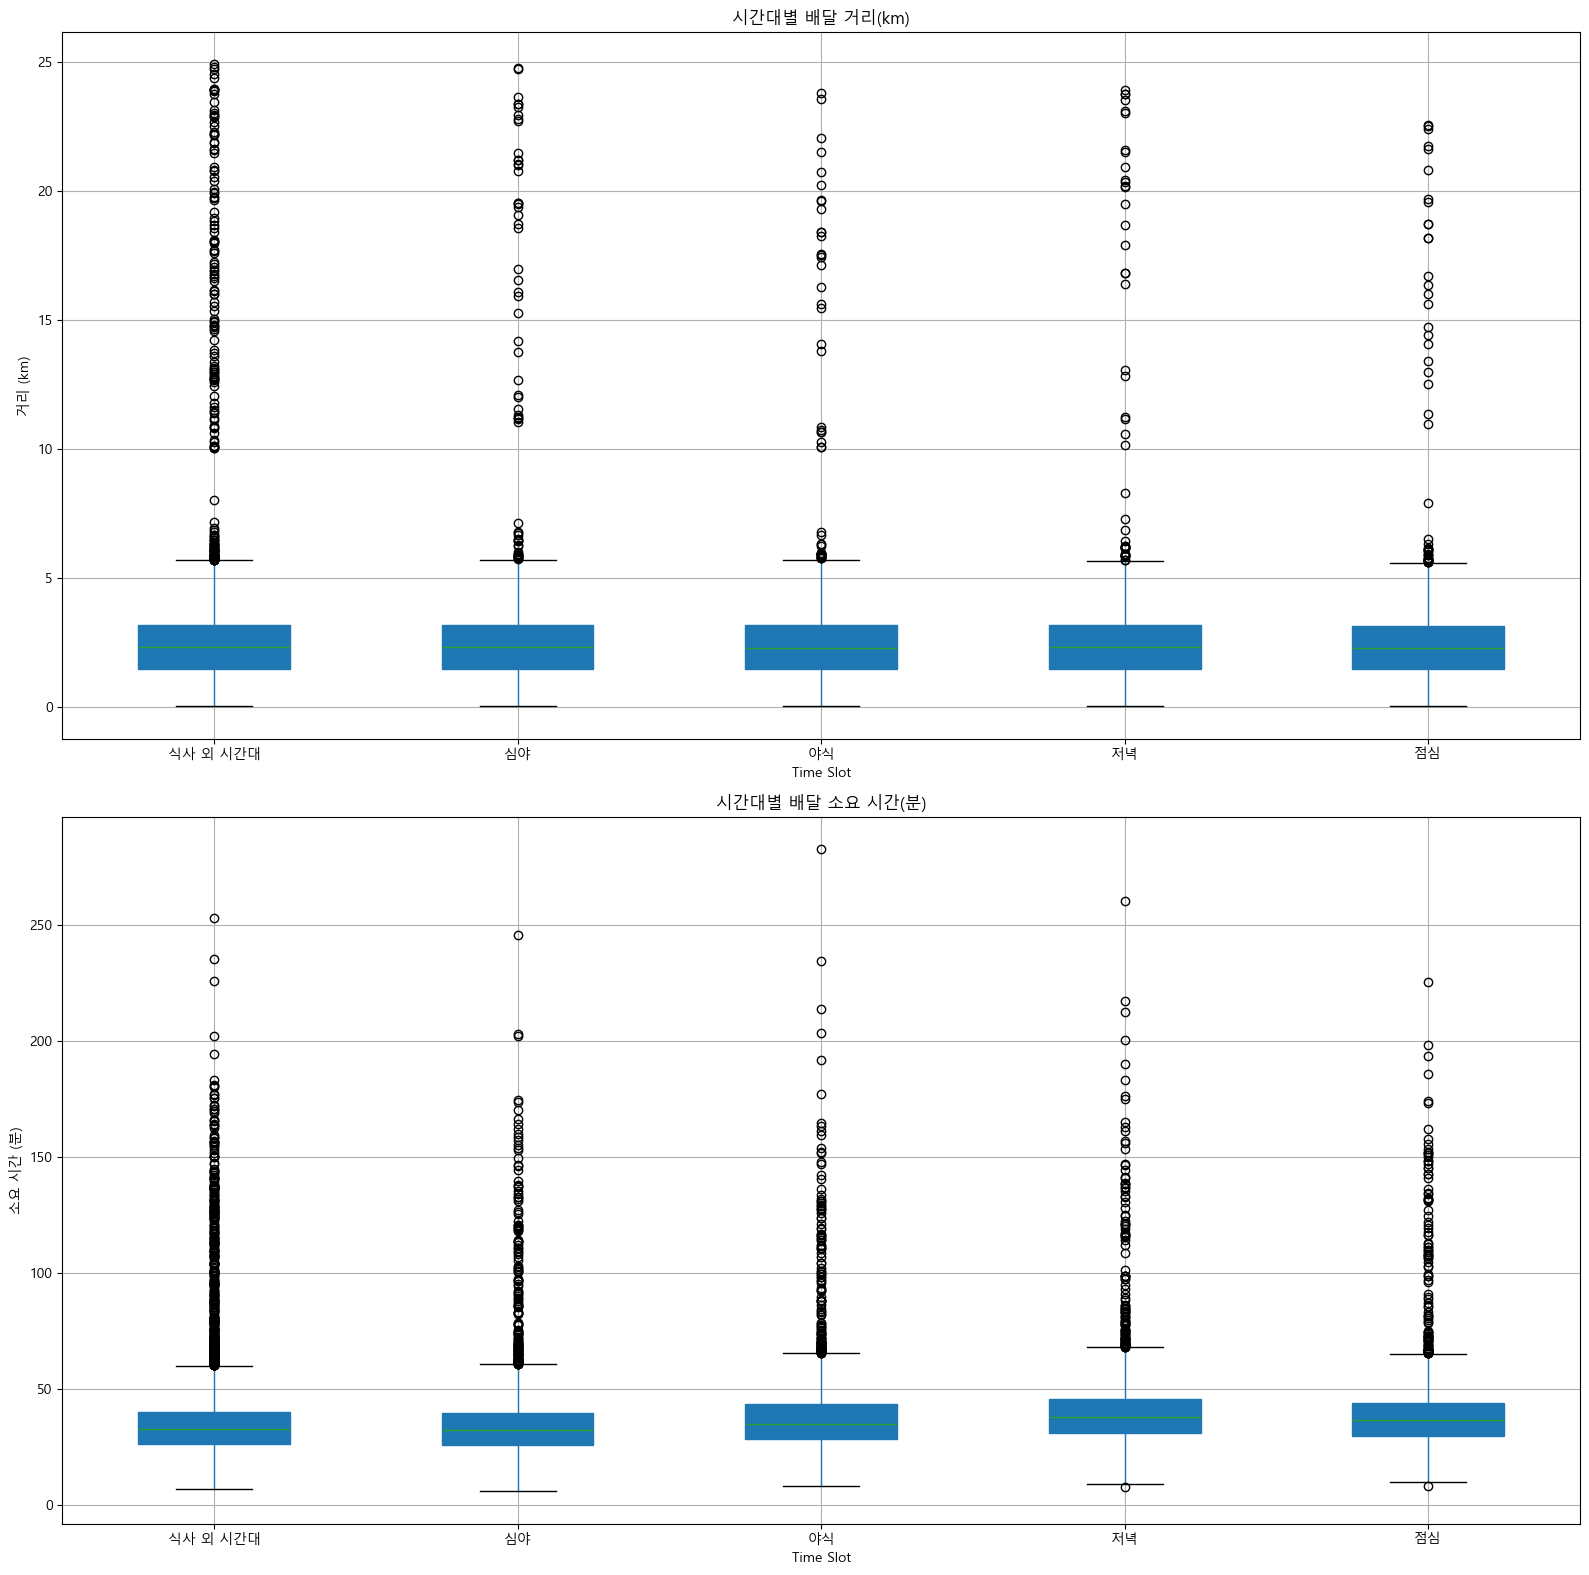

In [78]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 16))

# distance_km와 time_slot의 관계 그래프
df.boxplot(column='distance_km', by='time_slot', ax=ax1, patch_artist=True)
ax1.set_title('시간대별 배달 거리(km)')
ax1.set_xlabel('Time Slot')
ax1.set_ylabel('거리 (km)')

# delivery_minutes와 time_slot의 관계 그래프
df.boxplot(column='delivery_minutes', by='time_slot', ax=ax2, patch_artist=True)
ax2.set_title('시간대별 배달 소요 시간(분)')
ax2.set_xlabel('Time Slot')
ax2.set_ylabel('소요 시간 (분)')

plt.suptitle('') 
plt.tight_layout()
plt.show()